# Generative AI: Arabic Poetry

**Author:** Belal Nwiran

**Dataset:** [Ashaar](https://huggingface.co/datasets/arbml/ashaar)

This project trains a character-level Transformer (GPT style) to generate classical Arabic poetry. The task is to write a poem with a chosen number of lines, from an empty start or from a given start text. The model is trained from scratch in PyTorch on Abbasid-era poems, and the generated poems are evaluated by reading them.

**Source:** Hugging Face (link above), two parquet files with 127,315 poems each (254,630 poems in total), downloaded on 2026-10-03 (commit 9b5e723df1c5b13b9e4428caff758fe2f3c737f6), unmodified. The notebook keeps the Abbasid era and cleans it to 29,707 poems.

**Dataset access:** Download the two parquet files from the Hugging Face link above (Files and versions, folder `data`) and place them in the same folder as this notebook. The data are real poems (not synthetic or AI-generated), publicly available for research use only, and were not used in any earlier capstone project. The cleaned subset is

# Setup

In [1]:
import math
import random
import re
import time
import unicodedata

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F

from collections import Counter

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


# Dataset Inspection

## Data source

The dataset is **Ashaar**, a collection of Arabic poems published on Hugging Face.

- **URL:** https://huggingface.co/datasets/arbml/ashaar
- **Downloaded:** 2026-10-03
- **Version:** commit 9b5e723df1c5b13b9e4428caff758fe2f3c737f6
- **Files:** two parquet files with 127,315 poems each (254,630 poems in total)
- **License:** released for research use only (fair use). It must not be used commercially, and poets can ask to have their work removed.
- **Origin:** the poem URLs in the data point to aldiwan.net, so the poems were collected from that website.

Only the columns needed for this project are loaded (title, meter, verses, theme, URL, poet name, poet era).

## Dataset files in this repository

The two original Ashaar files (`train-00000-of-00002.parquet` and `train-00001-of-00002.parquet`, about 280 MB in total) are **not included** in this repository because they are too large.

The repository includes only the cleaned subset:

- **File:** `abbasid_filtered.parquet`
- **Content:** 29,726 Abbasid-era poems from 634 poets (29,707 after the text normalization below, which is applied after loading this file), with the columns `poem title`, `poem meter`, `poem verses`, `poem theme`, `poem url`, `poet name`, `poet era`, `n_hemistichs` and `n_chars`.
- **Made by:** the cleaning steps in this notebook (duplicates, era filter, empty poems, odd number of half-lines, length cap)

**To rebuild the subset from the original data:**

1. Download the two parquet files from https://huggingface.co/datasets/arbml/ashaar (commit 9b5e723df1c5b13b9e4428caff758fe2f3c737f6) and place them where the notebook is located.
2. Run the notebook from the top. The cleaning cells recreate `abbasid_filtered.parquet`.

**To rerun the project without the original files:** skip the loading and cleaning cells and read the subset directly:

`poems = pd.read_parquet("abbasid_filtered.parquet")`

The subset comes from the Ashaar dataset, which is released for research use only. It must not be used commercially, and poets can ask to have their work removed. The same terms apply to the subset in this repository.

In [3]:
cols = ["poem title", "poem meter", "poem verses", "poem theme",
        "poem url", "poet name", "poet era"]
files = ["train-00000-of-00002.parquet",
         "train-00001-of-00002.parquet"]

parts = [pd.read_parquet(f, columns=cols) for f in files]
print([len(p) for p in parts])
df = pd.concat(parts, ignore_index=True)

[127315, 127315]


In [4]:
print(df.shape)
print(df.dtypes)
print(df["poem url"].duplicated().sum(), "duplicate poem URLs")

(254630, 7)
poem title        str
poem meter        str
poem verses    object
poem theme        str
poem url          str
poet name         str
poet era          str
dtype: object
38 duplicate poem URLs


In [5]:
print(df["poet era"].value_counts())

poet era
العصر الحديث        55137
العصر العباسي       30413
العصر المملوكي      19059
العصر العثماني      11872
المغرب والأندلس      6614
العصر الفاطمي        4939
العصر الأندلسي       4770
العصر الأموي         3958
العصر الأيوبي        3125
المخضرمين            1975
العصر الجاهلي        1873
قبل الإسلام          1786
عصر بين الدولتين     1416
العصر الإسلامي        484
Name: count, dtype: int64


The dataset covers 14 eras. The Abbasid era has 30,413 poems, the largest after the modern era.

# Dataset Cleaning

In [6]:
def add_length_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Add hemistich count and character count per poem."""
    df = df.copy()
    df["n_hemistichs"] = df["poem verses"].apply(len)
    df["n_chars"] = df["poem verses"].apply(lambda v: sum(len(h) for h in v))
    print(f"add_length_columns: added n_hemistichs and n_chars for {len(df):,} poems")
    return df

In [7]:
def filter_era(df: pd.DataFrame, era: str) -> pd.DataFrame:
    """Keep only poems whose poet belongs to the given era."""
    df = df.copy()
    before = len(df)
    df = df[df["poet era"] == era]
    print(f"filter_era: kept {len(df):,} of {before:,} poems (era = {era})")
    return df

In [8]:
def drop_empty_poems(df: pd.DataFrame) -> pd.DataFrame:
    """Drop poems with no hemistichs."""
    df = df.copy()
    before = len(df)
    df = df[df["n_hemistichs"] > 0]
    print(f"drop_empty_poems: dropped {before - len(df):,} poems")
    return df

In [9]:
def drop_odd_hemistichs(df: pd.DataFrame) -> pd.DataFrame:
    """Drop poems with an odd number of hemistichs (broken sadr/ajuz pairing)."""
    df = df.copy()
    before = len(df)
    df = df[df["n_hemistichs"] % 2 == 0]
    print(f"drop_odd_hemistichs: dropped {before - len(df):,} poems")
    return df

In [10]:
def drop_long_poems(df: pd.DataFrame, max_hemistichs: int) -> pd.DataFrame:
    """Drop poems longer than max_hemistichs (long urjuzas, likely merged scrapes)."""
    df = df.copy()
    before = len(df)
    chars_before = df["n_chars"].sum()
    df = df[df["n_hemistichs"] <= max_hemistichs]
    share = 1 - df["n_chars"].sum() / chars_before
    print(
        f"drop_long_poems: dropped {before - len(df):,} poems "
        f"(> {max_hemistichs} hemistichs), {share:.1%} of characters"
    )
    return df

In [11]:
def drop_duplicate_poems(df: pd.DataFrame) -> pd.DataFrame:
    """Drop poems that appear twice (same poem URL), keeping the first."""
    df = df.copy()
    before = len(df)
    df = df.drop_duplicates(subset="poem url", keep="first")
    print(f"drop_duplicate_poems: dropped {before - len(df):,} poems")
    return df

In [12]:
ERA = "العصر العباسي"
CAP_QUANTILE = 0.99

poems = add_length_columns(df)
poems = filter_era(poems, ERA)
poems = drop_duplicate_poems(poems)
poems = drop_empty_poems(poems)
poems = drop_odd_hemistichs(poems)

max_hemistichs = int(poems["n_hemistichs"].quantile(CAP_QUANTILE))
print(f"Length cap ({CAP_QUANTILE:.0%} quantile): {max_hemistichs} hemistichs")
poems = drop_long_poems(poems, max_hemistichs)

poems = poems.reset_index(drop=True)
print(f"{len(poems):,} poems, {poems['n_chars'].sum() / 1e6:.1f}M characters")

add_length_columns: added n_hemistichs and n_chars for 254,630 poems
filter_era: kept 30,413 of 254,630 poems (era = العصر العباسي)
drop_duplicate_poems: dropped 0 poems
drop_empty_poems: dropped 1 poems
drop_odd_hemistichs: dropped 390 poems
Length cap (99% quantile): 156 hemistichs
drop_long_poems: dropped 296 poems (> 156 hemistichs), 12.6% of characters
29,726 poems, 15.6M characters


## Cleaning rules

The cleaning has five steps. Each step prints how many poems it removes.

1. **Remove duplicate poems.** 38 poem URLs appear twice in the full dataset, but none of the duplicate pairs are in the Abbasid era, so this step removes 0 poems. It stays as a safeguard.
2. **Keep the Abbasid era only.** The dataset is large, so one era is used. This gives one consistent style and enough text. The Abbasid era is the largest era after the modern era (modern poems may still be under copyright).
3. **Remove empty poems.** A poem with no text cannot be used.
4. **Remove poems with an odd number of half-lines.** A half-line is missing or extra, so the pairing of first and second halves is broken for the rest of the poem.
5. **Remove very long poems.** The limit is the 99th percentile of the number of half-lines (156). About 1% of poems are removed, but they hold 12.6% of all characters, so a few very long poems would otherwise have a large influence on what the model learns.

In [13]:
poet_share = poems.groupby("poet name")["n_chars"].sum().sort_values(ascending=False)
print(poems["poet name"].nunique(), "poets")
print((poet_share.head(10) / poet_share.sum()).round(3))

634 poets
poet name
البحتري              0.068
ابن الرومي           0.067
الشريف الرضي         0.063
أبو العلاء المعري    0.051
مهيار الديلمي        0.043
ابن نباتة السعدي     0.034
ابو نواس             0.033
أبو تمام             0.032
السري الرفاء         0.028
الصنوبري             0.028
Name: n_chars, dtype: float64


The data is concentrated in a few poets: the top 10 poets write 44.7% of the text, and the largest, البحتري, writes 6.8%. The model will therefore mostly learn the style of these poets. This is discussed in the ethics section of the report.

In [14]:
poems.to_parquet("abbasid_filtered.parquet", index=False)

After cleaning, 29,726 poems remain, with 15.6 million characters from 634 poets. The cleaned data is saved to `abbasid_filtered.parquet`.

## Data structure

Each row is one poem. The `poem verses` column is a list of **half-lines (hemistichs)**. A line of poetry (*bayt*) has two halves: the first half (*ṣadr*) and the second half (*ʿajuz*). The list alternates between them, so the number of lines is half the number of items.

The cell below shows  the first lines (up to five) of one poem, with the two halves side by side.

In [15]:
s = poems.iloc[0]
print(s["poet name"], "|", s["poem title"], "|", s["poem meter"])
for sadr, ajuz in zip(s["poem verses"][0:10:2], s["poem verses"][1:10:2]):
    print(sadr, "   ...   ", ajuz)

الشريف الرضي | ودجى هتكت قناعه | بحر مجزوء الكامل
وَدُجىً هَتَكتُ قِناعَهُ    ...    عَن وَجهِ طامِسَةٍ خَفِيَّه
تَسري كَواكِبُهُ إِلى ال    ...    إِصباحِ وَاللَيلُ المَطِيَّه
وَالنَجمُ وَجهُ مُقَبَّلٍ    ...    وَالبَدرُ مِرآةٌ صَدِيَّه


In [16]:
text = "".join("".join(v) for v in poems["poem verses"])
counts = Counter(text)
print(f"{len(text):,} characters, {len(counts)} unique")

def is_letter(c: str) -> bool:
    # Arabic letters, excluding tatweel (U+0640)
    return "\u0621" <= c <= "\u063A" or "\u0641" <= c <= "\u064A"

def is_diacritic(c: str) -> bool:
    return "\u064B" <= c <= "\u0652" or c == "\u0670"

print(sum(is_letter(c) for c in counts), "Arabic letters")
print(sum(is_diacritic(c) for c in counts), "diacritic marks")

for c, n in counts.most_common():
    if not is_letter(c) and not is_diacritic(c):
        print(repr(c), f"U+{ord(c):04X}", unicodedata.name(c, "?"), f"{n:,}")

15,612,370 characters, 74 unique
36 Arabic letters
8 diacritic marks
' ' U+0020 SPACE 1,790,601
'ـ' U+0640 ARABIC TATWEEL 1,141,081
'،' U+060C ARABIC COMMA 602
'.' U+002E FULL STOP 427
'"' U+0022 QUOTATION MARK 373
':' U+003A COLON 189
'؟' U+061F ARABIC QUESTION MARK 167
'!' U+0021 EXCLAMATION MARK 38
'؛' U+061B ARABIC SEMICOLON 15
'(' U+0028 LEFT PARENTHESIS 14
')' U+0029 RIGHT PARENTHESIS 14
'-' U+002D HYPHEN-MINUS 13
'@' U+0040 COMMERCIAL AT 8
'\u200d' U+200D ZERO WIDTH JOINER 6
'E' U+0045 LATIN CAPITAL LETTER E 4
'[' U+005B LEFT SQUARE BRACKET 3
'C' U+0043 LATIN CAPITAL LETTER C 2
'N' U+004E LATIN CAPITAL LETTER N 2
'T' U+0054 LATIN CAPITAL LETTER T 2
'R' U+0052 LATIN CAPITAL LETTER R 2
']' U+005D RIGHT SQUARE BRACKET 2
'4' U+0034 DIGIT FOUR 2
'ک' U+06A9 ARABIC LETTER KEHEH 1
'/' U+002F SOLIDUS 1
'=' U+003D EQUALS SIGN 1
'8' U+0038 DIGIT EIGHT 1
'a' U+0061 LATIN SMALL LETTER A 1
'7' U+0037 DIGIT SEVEN 1
'\u200c' U+200C ZERO WIDTH NON-JOINER 1
'd' U+0064 LATIN SMALL LETTER D 1


## Text normalization

The model reads the poems one character at a time, so the text is cleaned to keep only the Arabic letters and the space. The rules come from the character count of the cleaned subset above (74 unique characters, 15.6 million in total):

1. **Remove diacritics (tashkeel).** The poems carry 8 different diacritic marks, which split every letter into many variants and make the text longer. Without them the model has fewer symbols to learn.
2. **Remove tatweel (ـ).** It only stretches letters visually and has no meaning. It is 1,141,081 characters, 7.3% of the text.
3. **Remove zero-width joiner and non-joiner.** There are only 7 of them, and they sit inside words.
4. **Replace every other character with a space.** This covers punctuation, digits, Latin letters, brackets and symbols. Together they are about 1,900 characters (0.01%), too rare for the model to learn.
5. **Collapse repeated spaces** and trim the ends of each half-line.
6. **Remove poems with an empty half-line** after cleaning (19 poems), because the pairing of first and second halves would break.

Letter variants are not merged (for example أ, إ and ا stay different), so the spelling of the poems stays as written.

After normalization the text has 11 million characters and 37 unique characters (the Arabic letters and the space).

In [17]:
DIACRITICS = re.compile("[\u064B-\u0652\u0670]")
ZERO_WIDTH = re.compile("[\u200c\u200d]")
NOT_LETTER_OR_SPACE = re.compile("[^\u0621-\u063A\u0641-\u064A ]")
MANY_SPACES = re.compile(" +")


def normalize_text(text: str) -> str:
    """Keep only Arabic letters and single spaces."""
    text = DIACRITICS.sub("", text)
    text = text.replace("\u0640", "")          # tatweel
    text = ZERO_WIDTH.sub("", text)
    text = NOT_LETTER_OR_SPACE.sub(" ", text)  # punctuation, digits, Latin, etc.
    text = MANY_SPACES.sub(" ", text)
    return text.strip()


def normalize_poems(df: pd.DataFrame) -> pd.DataFrame:
    """Normalize every half-line of every poem and update n_chars."""
    df = df.copy()
    chars_before = df["n_chars"].sum()
    df["poem verses"] = df["poem verses"].apply(lambda v: [normalize_text(h) for h in v])
    df["n_chars"] = df["poem verses"].apply(lambda v: sum(len(h) for h in v))
    chars_after = df["n_chars"].sum()
    print(f"normalize_poems: {chars_before:,} -> {chars_after:,} characters "
          f"({1 - chars_after / chars_before:.1%} removed)")
    return df


def drop_poems_with_empty_halves(df: pd.DataFrame) -> pd.DataFrame:
    """Drop poems where a half-line became empty (breaks the pairing)."""
    df = df.copy()
    before = len(df)
    has_empty = df["poem verses"].apply(lambda v: any(h == "" for h in v))
    df = df[~has_empty]
    print(f"drop_poems_with_empty_halves: dropped {before - len(df):,} poems")
    return df

In [18]:
example = poems.iloc[0]["poem verses"][0]
print("before:", example)
print("after: ", normalize_text(example))

poems = normalize_poems(poems)
poems = drop_poems_with_empty_halves(poems)
poems = poems.reset_index(drop=True)

before: وَدُجىً هَتَكتُ قِناعَهُ
after:  ودجى هتكت قناعه
normalize_poems: 15,612,370 -> 11,014,129 characters (29.5% removed)
drop_poems_with_empty_halves: dropped 19 poems


In [19]:
text = "".join("".join(v) for v in poems["poem verses"])
print(f"{len(poems):,} poems, {len(text):,} characters, {len(set(text))} unique")
print("".join(sorted(set(text))))

29,707 poems, 11,011,086 characters, 37 unique
 ءآأؤإئابةتثجحخدذرزسشصضطظعغفقكلمنهوىي


In [20]:
HALF_SEP = "|"
LINE_END = "\n"
POEM_END = "#"


def poem_to_text(verses: list[str]) -> str:
    """Join half-lines into lines, and add the end-of-poem marker."""
    assert len(verses) % 2 == 0, "odd number of half-lines"
    lines = [f"{sadr}{HALF_SEP}{ajuz}" for sadr, ajuz in zip(verses[0::2], verses[1::2])]
    return LINE_END.join(lines) + LINE_END + POEM_END + LINE_END


def add_text_column(df: pd.DataFrame) -> pd.DataFrame:
    """Add one training text per poem, in the format used by the model."""
    df = df.copy()
    df["text"] = df["poem verses"].apply(poem_to_text)
    print(f"add_text_column: built text for {len(df):,} poems, "
          f"{df['text'].str.len().sum():,} characters")
    return df

In [21]:
poems = add_text_column(poems)

print(poems["text"].iloc[0][:300])

corpus = "".join(poems["text"])
print(f"{len(set(corpus))} unique characters")
print(repr("".join(sorted(set(corpus) - set(text)))))
print(poems["text"].str.len().describe())

add_text_column: built text for 29,707 poems, 11,557,072 characters
ودجى هتكت قناعه|عن وجه طامسة خفيه
تسري كواكبه إلى ال|إصباح والليل المطيه
والنجم وجه مقبل|والبدر مرآة صديه
#

40 unique characters
'\n#|'
count    29707.000000
mean       389.035312
std        578.820012
min         27.000000
25%        105.000000
50%        176.000000
75%        358.000000
max       4287.000000
Name: text, dtype: float64


## Text format for the model

The model needs to know where each half-line, each line and each poem ends. Three symbols that do not appear in the cleaned text are added:

- `|` between the first half (*ṣadr*) and the second half (*ʿajuz*) of a line
- a new line at the end of each line
- `#` after the last line of a poem, so the model learns where a poem stops

Each poem becomes one text string. Some words are split across the two halves of a line, so the separator is not always placed between two words.

The vocabulary is therefore 40 symbols: the 36 Arabic letters, the space and these three symbols.

## Train/validation split and encoding

The poems are shuffled (seed 42) and split by whole poem: 90% for training and 10% for validation. No poem appears in both sets.

The vocabulary is built from the training poems only. It has 40 symbols, and every symbol in the validation set is in it. Each split is turned into one long sequence of numbers.

The model is trained on random blocks of 256 symbols. The median poem is 176 characters and the 75th percentile is 358, so a block covers a typical poem and the end of the previous one. The target for each block is the same block shifted by one symbol, so at every position the model learns to predict the next symbol. Blocks can cross poem boundaries, which is fine because every poem ends with the `#` marker.

In [22]:
BLOCK_SIZE = 256
VAL_FRACTION = 0.1


def split_poems(df: pd.DataFrame, val_fraction: float, seed: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Shuffle the poems and split them into train and validation sets, poem by poem."""
    shuffled = df.sample(frac=1.0, random_state=seed)
    n_val = int(len(shuffled) * val_fraction)
    val = shuffled.iloc[:n_val].reset_index(drop=True)
    train = shuffled.iloc[n_val:].reset_index(drop=True)
    print(f"split_poems: {len(train):,} train poems, {len(val):,} validation poems")
    return train, val


def build_vocab(text: str) -> tuple[dict[str, int], dict[int, str]]:
    """Map every symbol in the text to an integer, and back."""
    symbols = sorted(set(text))
    stoi = {s: i for i, s in enumerate(symbols)}
    itos = {i: s for s, i in stoi.items()}
    print(f"build_vocab: {len(symbols)} symbols")
    return stoi, itos


def encode(text: str, stoi: dict[str, int]) -> torch.Tensor:
    """Turn a text into a 1-D tensor of integers."""
    return torch.tensor([stoi[s] for s in text], dtype=torch.long)


def decode(ids: torch.Tensor, itos: dict[int, str]) -> str:
    """Turn a 1-D tensor of integers back into text."""
    return "".join(itos[int(i)] for i in ids)


def get_batch(data: torch.Tensor, block_size: int, batch_size: int) -> tuple[torch.Tensor, torch.Tensor]:
    """Random blocks x, and the same blocks shifted by one symbol (y)."""
    starts = torch.randint(0, len(data) - block_size - 1, (batch_size,))
    x = torch.stack([data[s : s + block_size] for s in starts])
    y = torch.stack([data[s + 1 : s + block_size + 1] for s in starts])
    return x, y

In [23]:
train_poems, val_poems = split_poems(poems, VAL_FRACTION, SEED)

train_text = "".join(train_poems["text"])
val_text = "".join(val_poems["text"])

stoi, itos = build_vocab(train_text)
print("validation symbols missing from the vocabulary:", set(val_text) - set(stoi))

train_data = encode(train_text, stoi)
val_data = encode(val_text, stoi)
print(f"train: {len(train_data):,} symbols, validation: {len(val_data):,} symbols")

x, y = get_batch(train_data, BLOCK_SIZE, 2)
print(x.shape, y.shape)
print(repr(decode(x[0][:40], itos)))
print(repr(decode(y[0][:40], itos)))

split_poems: 26,737 train poems, 2,970 validation poems
build_vocab: 40 symbols
validation symbols missing from the vocabulary: set()
train: 10,407,255 symbols, validation: 1,149,817 symbols
torch.Size([2, 256]) torch.Size([2, 256])
'تطب الش|ر يجد عنده وقود الحرب\nأسمرا كالر'
'طب الش|ر يجد عنده وقود الحرب\nأسمرا كالرش'


## Model architecture

The model is a small decoder-only Transformer (GPT style) that reads 256 symbols and predicts the next symbol at every position. A decoder-only model with a causal mask fits text generation: it is trained to predict the next symbol and it generates one symbol at a time.

- **Size:** 6 layers, 6 attention heads, 384-dimensional embeddings, feed-forward size 1,536. This gives 10,776,576 parameters, about one parameter per training symbol (10.4 million).
- **Causal mask:** each position can only attend to earlier positions. A check in the notebook shows that changing later symbols does not change earlier predictions.
- **Dropout 0.1:** mild regularization, because the data is large for a model of this size.
- **Vocabulary:** 40 symbols, so the input and output layers are very small and almost all parameters are in the Transformer blocks.

The sizes follow the character-level example in Andrej Karpathy's nanoGPT project. The code was written for this project in plain PyTorch. **nanoGPT:** https://github.com/karpathy/nanoGPT

In [24]:
VOCAB_SIZE = len(stoi)
N_LAYER = 6
N_HEAD = 6
N_EMBD = 384
DROPOUT = 0.1


class CausalSelfAttention(nn.Module):
    """Multi-head self-attention where each position only sees earlier positions."""

    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        assert n_embd % n_head == 0, "n_embd must be divisible by n_head"
        self.n_head = n_head
        self.qkv = nn.Linear(n_embd, 3 * n_embd)
        self.proj = nn.Linear(n_embd, n_embd)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        mask = torch.tril(torch.ones(block_size, block_size)).view(1, 1, block_size, block_size)
        self.register_buffer("mask", mask)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        head_size = C // self.n_head
        q, k, v = self.qkv(x).split(C, dim=2)
        q = q.view(B, T, self.n_head, head_size).transpose(1, 2)  # (B, heads, T, head_size)
        k = k.view(B, T, self.n_head, head_size).transpose(1, 2)
        v = v.view(B, T, self.n_head, head_size).transpose(1, 2)
        scores = q @ k.transpose(-2, -1) / math.sqrt(head_size)    # (B, heads, T, T)
        scores = scores.masked_fill(self.mask[:, :, :T, :T] == 0, float("-inf"))
        weights = self.attn_drop(F.softmax(scores, dim=-1))
        out = (weights @ v).transpose(1, 2).contiguous().view(B, T, C)
        return self.resid_drop(self.proj(out))


class FeedForward(nn.Module):
    """Two linear layers with a GELU in between, applied to each position."""

    def __init__(self, n_embd: int, dropout: float):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):
    """One Transformer block: attention, then feed-forward, each with a residual connection."""

    def __init__(self, n_embd: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.attn = CausalSelfAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff = FeedForward(n_embd, dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x


class CharGPT(nn.Module):
    """Decoder-only Transformer that predicts the next symbol at every position."""

    def __init__(self, vocab_size: int, block_size: int, n_layer: int,
                 n_head: int, n_embd: int, dropout: float):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, n_embd)
        self.pos_emb = nn.Embedding(block_size, n_embd)
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.Sequential(
            *[Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)]
        )
        self.ln_f = nn.LayerNorm(n_embd)
        self.head = nn.Linear(n_embd, vocab_size, bias=False)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx: torch.Tensor, targets: torch.Tensor | None = None):
        B, T = idx.shape
        pos = torch.arange(T, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        x = self.blocks(x)
        logits = self.head(self.ln_f(x))                          # (B, T, vocab)
        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))
        return logits, loss

In [25]:
model = CharGPT(VOCAB_SIZE, BLOCK_SIZE, N_LAYER, N_HEAD, N_EMBD, DROPOUT).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"{n_params:,} parameters")

x, y = get_batch(train_data, BLOCK_SIZE, 4)
logits, loss = model(x.to(device), y.to(device))
print(logits.shape, f"initial loss {loss.item():.3f} (random guess: {math.log(VOCAB_SIZE):.3f})")

# Causality check: changing symbols after position 100 must not change earlier predictions
model.eval()
with torch.no_grad():
    x1 = x.to(device)
    x2 = x1.clone()
    x2[:, 100:] = torch.randint(0, VOCAB_SIZE, x2[:, 100:].shape, device=device)
    l1, _ = model(x1)
    l2, _ = model(x2)
print("predictions before position 100 unchanged:", torch.allclose(l1[:, :100], l2[:, :100], atol=1e-5))

10,776,576 parameters
torch.Size([4, 256, 40]) initial loss 3.717 (random guess: 3.689)
predictions before position 100 unchanged: True


## Training setup

- **Loss:** cross-entropy between the predicted scores and the next symbol, at every position of every block.
- **Optimizer:** AdamW with a learning rate of 3e-4. It rises over 200 steps and then decays along a cosine curve to 3e-5.
- **Batch:** 64 random blocks of 256 symbols (16,384 symbols per step). 5,000 steps is about 8 passes over the 10.4 million training symbols.
- **Stability:** gradients are clipped at 1.0, and the GPU uses bfloat16 mixed precision to save time and memory.
- **Monitoring:** every 250 steps the loss is measured on 50 random training batches and 50 random validation batches, with dropout off. The model with the lowest validation loss is saved.

In [26]:
BATCH_SIZE = 64
MAX_STEPS = 5000
LEARNING_RATE = 3e-4
MIN_LR = 3e-5
WARMUP_STEPS = 200
EVAL_INTERVAL = 250
EVAL_BATCHES = 50
GRAD_CLIP = 1.0
CHECKPOINT = "best_model.pt"


def get_lr(step: int) -> float:
    """Linear warm-up, then cosine decay down to MIN_LR."""
    if step < WARMUP_STEPS:
        return LEARNING_RATE * (step + 1) / WARMUP_STEPS
    progress = (step - WARMUP_STEPS) / (MAX_STEPS - WARMUP_STEPS)
    return MIN_LR + 0.5 * (1 + math.cos(math.pi * progress)) * (LEARNING_RATE - MIN_LR)


@torch.no_grad()
def estimate_loss(model: nn.Module, data: torch.Tensor) -> float:
    """Average loss over EVAL_BATCHES random batches, with dropout off."""
    model.eval()
    losses = []
    for _ in range(EVAL_BATCHES):
        x, y = get_batch(data, BLOCK_SIZE, BATCH_SIZE)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            _, loss = model(x.to(device), y.to(device))
        losses.append(loss.item())
    model.train()
    return sum(losses) / len(losses)


def train_model(model: nn.Module, train_data: torch.Tensor, val_data: torch.Tensor) -> dict[str, list[float]]:
    """Train the model. Returns the loss history and saves the best model (lowest validation loss)."""
    optimizer = torch.optim.AdamW(
        model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.95), weight_decay=0.01
    )
    history = {"step": [], "train_loss": [], "val_loss": []}
    best_val = float("inf")
    start = time.time()
    model.train()

    for step in range(MAX_STEPS + 1):
        lr = get_lr(step)

        if step % EVAL_INTERVAL == 0 or step == MAX_STEPS:
            train_loss = estimate_loss(model, train_data)
            val_loss = estimate_loss(model, val_data)
            history["step"].append(step)
            history["train_loss"].append(train_loss)
            history["val_loss"].append(val_loss)
            if val_loss < best_val:
                best_val = val_loss
                torch.save(model.state_dict(), CHECKPOINT)
            print(f"step {step:5d} | train {train_loss:.4f} | val {val_loss:.4f} "
                  f"| lr {lr:.2e} | {(time.time() - start) / 60:.1f} min")

        if step == MAX_STEPS:
            break

        for group in optimizer.param_groups:
            group["lr"] = lr
        x, y = get_batch(train_data, BLOCK_SIZE, BATCH_SIZE)
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            _, loss = model(x.to(device), y.to(device))
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()

    return history

In [27]:
torch.manual_seed(SEED)
model = CharGPT(VOCAB_SIZE, BLOCK_SIZE, N_LAYER, N_HEAD, N_EMBD, DROPOUT).to(device)
history = train_model(model, train_data, val_data)

step     0 | train 3.8378 | val 3.8394 | lr 1.50e-06 | 0.1 min
step   250 | train 2.5813 | val 2.5849 | lr 3.00e-04 | 0.5 min
step   500 | train 2.2934 | val 2.2972 | lr 2.97e-04 | 0.9 min
step   750 | train 2.1399 | val 2.1429 | lr 2.91e-04 | 1.4 min
step  1000 | train 2.0468 | val 2.0499 | lr 2.82e-04 | 1.8 min
step  1250 | train 1.9932 | val 1.9931 | lr 2.69e-04 | 2.2 min
step  1500 | train 1.9447 | val 1.9448 | lr 2.54e-04 | 2.7 min
step  1750 | train 1.9118 | val 1.9135 | lr 2.36e-04 | 3.1 min
step  2000 | train 1.8852 | val 1.8909 | lr 2.17e-04 | 3.6 min
step  2250 | train 1.8621 | val 1.8723 | lr 1.96e-04 | 4.0 min
step  2500 | train 1.8427 | val 1.8541 | lr 1.74e-04 | 4.4 min
step  2750 | train 1.8294 | val 1.8396 | lr 1.52e-04 | 4.8 min
step  3000 | train 1.8193 | val 1.8300 | lr 1.30e-04 | 5.3 min
step  3250 | train 1.7989 | val 1.8186 | lr 1.09e-04 | 5.7 min
step  3500 | train 1.7944 | val 1.8062 | lr 9.00e-05 | 6.2 min
step  3750 | train 1.7794 | val 1.7947 | lr 7.27e-05 | 

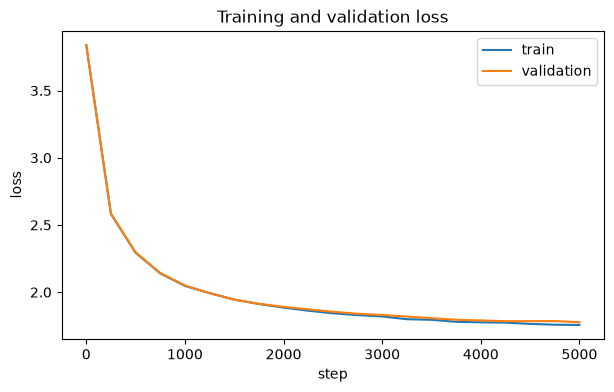

In [28]:
plt.figure(figsize=(7, 4))
plt.plot(history["step"], history["train_loss"], label="train")
plt.plot(history["step"], history["val_loss"], label="validation")
plt.xlabel("step")
plt.ylabel("loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [29]:
best_val = min(history["val_loss"])
best_step = history["step"][history["val_loss"].index(best_val)]
print(f"best validation loss {best_val:.3f} at step {best_step} "
      f"(perplexity per character: {math.exp(best_val):.2f})")

best validation loss 1.777 at step 5000 (perplexity per character: 5.91)


In [30]:
model.load_state_dict(torch.load(CHECKPOINT, map_location=device));

## Training results

Training took 8.8 minutes on the RTX 4070. The validation loss fell from 3.84 at step 0 (random guessing among 40 symbols gives 3.69) to 1.777 at step 5,000, a perplexity of about 5.9 per character. Most of the improvement came in the first 1,000 steps (validation loss 2.05).

The training and validation losses stay close together (1.756 and 1.777 at the end, and the gap never exceeds 0.03), so the model is not overfitting. It is limited by training time and size instead. Progress slows as the learning rate decays: from step 4,000 to step 5,000 the validation loss fell only from 1.790 to 1.777. There is no sign of instability at the evaluation points. The best model is the one from step 5,000.

## Generating poems

The function `generate(start, n_bayts)` writes a poem of `n_bayts` lines. It begins with the text `start` (which can be empty) and adds one symbol at a time. At each step the model gives a probability for each of the 40 symbols, and one symbol is picked at random from the 20 most likely ones. The model starts from the end of a previous poem (`#` and a new line), which is what it saw at the start of every poem in training. The end marker is blocked, so every poem has exactly the requested number of lines.

Sampling is controlled by two settings:

- **Temperature** divides the scores before they become probabilities. Low values make the model choose the most likely symbols, and high values make it more varied and less reliable.
- **Top-k (k = 20)** keeps only the 20 most likely symbols at each step.

Poems of 4 bayts are generated at temperatures 0.5, 0.8 and 1.0, with three samples each. The same seeds are used at every temperature, so differences come from the temperature only.

In [31]:
TOP_K = 20
MAX_SYMBOLS_PER_BAYT = 200


@torch.no_grad()
def generate(start: str, n_bayts: int, temperature: float = 0.8, seed: int | None = None) -> str:
    """Write a poem of n_bayts lines, beginning with `start` (which may be empty).

    Uses the trained `model`, `stoi` and `itos` of the notebook. Lines already in `start` count.
    """
    assert temperature > 0, "temperature must be positive"
    unknown = set(start) - set(stoi)
    assert not unknown, f"start has symbols outside the vocabulary: {unknown}"

    model.eval()
    generator = torch.Generator(device=device)
    if seed is not None:
        generator.manual_seed(seed)

    begin = POEM_END + LINE_END  # the end of a previous poem, so the model starts a new one
    ids = encode(begin + start, stoi).unsqueeze(0).to(device)
    n_lines = start.count(LINE_END)
    end_id = stoi[POEM_END]

    for _ in range(n_bayts * MAX_SYMBOLS_PER_BAYT):
        if n_lines >= n_bayts:
            break
        context = ids[:, -model.block_size:]
        with torch.autocast(device_type=device.type, dtype=torch.bfloat16):
            logits, _ = model(context)
        logits = logits[:, -1, :].float() / temperature
        logits[:, end_id] = float("-inf")  # do not end the poem before n_bayts lines
        top_values, _ = torch.topk(logits, min(TOP_K, logits.size(-1)))
        logits[logits < top_values[:, [-1]]] = float("-inf")
        next_id = torch.multinomial(F.softmax(logits, dim=-1), num_samples=1, generator=generator)
        ids = torch.cat([ids, next_id], dim=1)
        n_lines += int(itos[next_id.item()] == LINE_END)

    return decode(ids[0, len(begin):], itos).rstrip(LINE_END)

In [32]:
TEMPERATURES = [0.5, 0.8, 1.0]
SAMPLES_PER_TEMPERATURE = 3
N_BAYTS = 4

samples = {}
for t in TEMPERATURES:
    samples[t] = [
        generate("", N_BAYTS, temperature=t, seed=SEED + i)
        for i in range(SAMPLES_PER_TEMPERATURE)
    ]
    print(f"===== temperature {t} =====")
    for i, poem in enumerate(samples[t], start=1):
        print(f"--- sample {i} ---")
        print(poem)
        print()

===== temperature 0.5 =====
--- sample 1 ---
ألا أيها الدهر أن يعاد به|فلم يدر إلا الدهر والأعدا
وما له ما قد شاء به وجهه|ولكنه في الأعداء مستندا
ولا أمل إلا في الأمر من خده|ولا أملك الأمر إلا وإن أملا
ولا تدري الأيام بعد ما أرى|ما أنا في الأمر أعدائه أملا

--- sample 2 ---
تنازع الملك الذي ينزع الدن|وينزع الحسن من فضل الملك
وتحسب الخلق الذي أراكه|وتحسب الذي أملكه الملك
ألا في العيش المرء الذي لم يكن|لسان من الناس من المعتلك
إن الذي يكن الذي لا تجددني|إلى ما أن تحت المحل والمرك

--- sample 3 ---
ولا أن تبدل الرعد الشباب لقد|أولى به الشيب الذي يبدل
وقد كنت أبدا لكم من عرض|وأعرضت من الأمر في المنسك العذل
وكنت أبدا من يوم أبدا|وأنت أبدا من ألسنة المنسك
ألا إن يكن الخطيب في كل من|جواد يوما لم يكن في المنسك النسك

===== temperature 0.8 =====
--- sample 1 ---
ألا سائل سائلها محكما|أنا فلم يدر عليها عواليها
على الشعر عواتقها عيونا|وجهك بالعيون عن المتلواتيها
وكنت أمشي على العيون مشاربا|بنات المكرمات وليس رواها
ولكن بالرداء الأيام رداءها|وأبدلها بالفوارس من أعاديها

--- sample 2 ---
تنازع المل

In [33]:
print(generate("يا ليل", 4, seed=SEED))

يا ليلة أرضاها سهامها|محكما يسري لها في الحلل
هواء مستعذرا من لهوته|وهو عذراء مجدك من علل
وليلة متلوك إن تكن بها|شيئا بما عاينته الختل
وليلة من كل يوم محرم|وأحل بما أحلى عليها بالصل


## Qualitative evaluation of the generated poems

Nine poems of four lines were generated (three at each temperature), plus one poem from a given start. The model learned the **form** of classical poetry well, but not its **meaning**.

### Strengths

- **Line format.** All 36 generated lines have exactly one `|`, and so do the 4 lines of the poem from a start, so the model learned the two-half structure.
- **Rhyme.** In 6 of the 9 poems, all four lines end with the same letter, and 32 of the 36 lines end with the main letter of their poem. This counts only the last letter, which is an easy test. For example, in sample 1 at temperature 0.5 the sound changes halfway from *-dā* to *-lā*. The clearest case is sample 3 at temperature 1.0: lines 1 to 3 end with three real rhyming words, *al-ʿadhāb* ("torment"), *al-riqāb* ("necks") and *al-ʿiqāb* ("punishment").
- **Classical phrases.** Some phrases look right, for example *banāt al-makrumāt* ("daughters of noble deeds", sample 1 at temperature 0.8, line 3) and *wa-mā min al-shiʿr illā wajdā* ("there is nothing in poetry but passion", sample 2 at temperature 0.8, line 3).
- **Using a start.** Given the start `يا ليل`, the model continued the word as `يا ليلة`, kept the format, and ended all four lines with the same letter, `ل`.

### Failure cases

- **No clear meaning.** Phrases are fluent one at a time, but the lines do not form one thought.
- **Repetition.** At temperature 0.5, all three poems repeat words. In sample 1, the same rhyme word `أملا` ends lines 3 and 4. In sample 2, `الملك` ends lines 1 and 2, and `الذي` appears six times. In sample 3, `أبدا` appears four times in lines 2 and 3, and `المنسك` appears in lines 2, 3 and 4. Repetition also appears at other temperatures, for example `القلب` ends lines 1 and 4 of sample 2 at temperature 1.0.
- **Invented words.** Examples are `المعتلك` (sample 2, temperature 0.5), `المتلواتيها` (sample 1, temperature 0.8), `القياسما` and `الرماسما` (sample 2, temperature 0.8), `ممطعما` (sample 1, temperature 1.0) and `الألوم` (sample 2, temperature 1.0). I could not find them as Arabic words. Several are rhyme words, so the model seems to invent word endings to keep the rhyme.
- **Grammar and spelling errors.** `فأرجوا` has an extra alif (sample 3, temperature 1.0, line 1), and `وتلك الحبيب` uses a feminine "that" with a masculine noun (sample 2, temperature 1.0, line 2).
- **Broken rhyme.** In 3 of the 9 poems the rhyme breaks. Sample 3 at temperature 0.5 changes from *-l* (lines 1 and 2) to *-k* (lines 3 and 4). In sample 3 at temperature 0.8, line 3 ends with `كري` while the others end with `ر`. In sample 3 at temperature 1.0, line 4 ends with `جنابي` while lines 1 to 3 end with *-āb*.

### Effect of temperature

Repetition was strongest at 0.5, where all three poems repeat words. Invented words were rare at 0.5 (one possible case) and more common at 0.8 and 1.0. Complete rhyme was the same at every temperature: 2 of 3 poems each. With only three poems per temperature, these are impressions and not trends.

The same seeds were used at every temperature, so the poems are not independent. For example, sample 2 starts with the same word, `تنازع`, at all three temperatures.

These poems match the training result: a perplexity of about 5.9 per character means the model is still often unsure of the next letter after 8.8 minutes of training, and the main weakness is meaning, not form.

## Summary

This notebook trains a small character-level GPT-style Transformer (10.8 million parameters) to generate classical Arabic poetry, using about 29,700 Abbasid-era poems from the Ashaar dataset. Training was stable and took 8.8 minutes, and the validation loss fell from 3.84 to 1.777 with no sign of overfitting, which suggests the model is limited by training time and size more than by the data. The main challenges came earlier, in data preparation: the text had diacritics, a large amount of tatweel (7.3% of the characters), and poems with an odd number of half-lines or a very long length, which were cleaned or removed. The generated poems follow the form well: all 36 generated lines have the two-half format, and 6 of 9 poems keep the same rhyme letter in all four lines. They fail on meaning, because the lines do not form a clear thought, and the poems contain repeated words, invented words, grammar and spelling errors and some broken rhymes. Whether the model copies lines from the training poems was not tested, so this remains an open question.